# LSEG Daily Returns fuer Euro500 Portfolio (Company Cache)

Ziel dieses Notebooks:
- Daily Returns fuer alle Aktien im `euro500` Portfolio ziehen
- RIC-Probleme minimieren: erst ISIN (stabil), nur dann RIC fallback
- Cache **pro Unternehmen** statt pro Quartal
- Finale Tabelle nur fuer Tage, an denen die Aktie im Index ist (exakte Mitgliedschaft)


## 1. Setup


In [1]:
from __future__ import annotations

import hashlib
import random
import re
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import lseg.data as ld

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")

pd.set_option("display.max_columns", 120)

BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
DATA_DIR = BASE_DIR / "intermediate"
TABLE_DIR = BASE_DIR / "tables"

CACHE_DIR = DATA_DIR / "daily_returns_cache_by_company"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = DATA_DIR / "daily_returns_company_cache_manifest.parquet"
OUTPUT_RETURNS_ALL = DATA_DIR / "daily_returns_company_all.parquet"
OUTPUT_RETURNS_IN_INDEX = DATA_DIR / "daily_returns_euro500_in_index.parquet"
OUTPUT_MISSING = DATA_DIR / "daily_returns_missing_companies.parquet"
LEGACY_RETURNS_PATH = DATA_DIR / "rets_daily_isin.parquet"

TARGET_END_DATE = pd.Timestamp("2025-12-31")

EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"File not found: {EURO500_PATH}")

print("EURO500 path:", EURO500_PATH)
print("Cache dir   :", CACHE_DIR)
print("Legacy file :", LEGACY_RETURNS_PATH, "exists:", LEGACY_RETURNS_PATH.exists())


EURO500 path: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
Cache dir   : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_cache_by_company
Legacy file : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/rets_daily_isin.parquet exists: False


## 2. Universe laden und Pull-ID pro Unternehmen bauen

Regel:
1. ISIN (primaer)
2. RIC_current
3. RIC


In [2]:
df = pd.read_parquet(EURO500_PATH).copy()

required = ["quarter", "formation_date", "effective_date", "ISIN", "RIC", "RIC_current"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in euro500: {missing_cols}")

# Ensure firm_id exists (backward compatible with older euro500 versions).
if "firm_id" not in df.columns:
    fid = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        fid = fid.fillna("SEDOL:" + v)

    df["firm_id"] = fid

for c in ["firm_id", "ISIN", "RIC", "RIC_current", "quarter"]:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip()
        df.loc[df[c] == "", c] = pd.NA

for c in ["formation_date", "effective_date", "date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Pull-ID je Portfolio-Zeile: ISIN first, sonst RIC_current, sonst RIC.
df["id_type"] = np.select(
    [df["ISIN"].notna(), df["RIC_current"].notna(), df["RIC"].notna()],
    ["ISIN", "RIC", "RIC"],
    default=pd.NA,
)

df["pull_id"] = np.select(
    [df["ISIN"].notna(), df["RIC_current"].notna(), df["RIC"].notna()],
    [df["ISIN"], df["RIC_current"], df["RIC"]],
    default=pd.NA,
)

df["company_key"] = df["id_type"].astype("string") + ":" + df["pull_id"].astype("string")
df.loc[df["pull_id"].isna(), "company_key"] = pd.NA

n_rows = len(df)
n_companies = df["company_key"].nunique(dropna=True)
print(f"Rows in euro500: {n_rows:,}")
print(f"Unique company_key: {n_companies:,}")
print("Rows without pull_id:", int(df["pull_id"].isna().sum()))


Rows in euro500: 54,000
Unique company_key: 1,428
Rows without pull_id: 0


## 3. Exakte Mitgliedschaftsfenster je Quartal

Mitgliedschaft pro Zeile gilt von `effective_date` bis einen Tag vor naechster `effective_date`.


In [3]:
quarter_calendar = (
    df[["quarter", "effective_date"]]
    .dropna()
    .drop_duplicates()
    .sort_values("effective_date")
    .reset_index(drop=True)
)
quarter_calendar["next_effective_date"] = quarter_calendar["effective_date"].shift(-1)

# Ende inklusiv: Tag vor naechster effective_date, hart gekappt auf TARGET_END_DATE.
max_end = TARGET_END_DATE
quarter_calendar["membership_end_date"] = quarter_calendar["next_effective_date"] - pd.Timedelta(days=1)
quarter_calendar["membership_end_date"] = quarter_calendar["membership_end_date"].fillna(max_end)
quarter_calendar["membership_end_date"] = quarter_calendar["membership_end_date"].clip(upper=max_end)

membership = df.merge(
    quarter_calendar[["quarter", "effective_date", "membership_end_date"]],
    on=["quarter", "effective_date"],
    how="left",
)

# Avoid duplicate date-column names from upstream inputs.
membership = membership.drop(columns=[c for c in ["start_date", "end_date"] if c in membership.columns])
membership["start_date"] = membership["effective_date"]
membership["end_date"] = membership["membership_end_date"]
membership = membership.drop(columns=["membership_end_date"])

membership = membership.dropna(subset=["company_key", "start_date", "end_date"]).copy()
membership = membership[membership["start_date"] <= membership["end_date"]].copy()

print("Membership rows:", len(membership))
print("Membership companies:", membership["company_key"].nunique())
print("Date range:", membership["start_date"].min().date(), "to", membership["end_date"].max().date())



Membership rows: 54000
Membership companies: 1428
Date range: 1999-01-01 to 2025-12-31


## 4. Cache- und Pull-Helfer

- Ein Cache-File pro `company_key`
- Bei vorhandenem Cache nur fehlende Datumssegmente nachladen


In [4]:
@dataclass
class PullResult:
    df: pd.DataFrame
    field_used: str | None
    mode_used: str | None


def _safe_name(company_key: str) -> str:
    h = hashlib.sha1(company_key.encode("utf-8")).hexdigest()[:12]
    clean = re.sub(r"[^A-Za-z0-9._-]", "_", company_key)
    return f"{clean[:80]}__{h}.parquet"


def cache_path_for_company(company_key: str) -> Path:
    return CACHE_DIR / _safe_name(company_key)


def _extract_single_series(raw: pd.DataFrame) -> pd.DataFrame:
    if raw is None or raw.empty:
        return pd.DataFrame(columns=["date", "value"])

    w = raw.copy().reset_index()
    if w.empty:
        return pd.DataFrame(columns=["date", "value"])

    # first column after reset_index should be date-like
    date_col = w.columns[0]
    w = w.rename(columns={date_col: "date"})
    w["date"] = pd.to_datetime(w["date"], errors="coerce")
    w = w.dropna(subset=["date"]).copy()

    value_col = None
    best_non_na = -1
    for c in w.columns:
        if c == "date":
            continue
        s = pd.to_numeric(w[c], errors="coerce")
        n = int(s.notna().sum())
        if n > best_non_na:
            best_non_na = n
            value_col = c

    if value_col is None or best_non_na <= 0:
        return pd.DataFrame(columns=["date", "value"])

    out = w[["date", value_col]].copy()
    out = out.rename(columns={value_col: "value"})
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    return out.dropna(subset=["value"]).copy()


def _values_to_returns(s: pd.Series, mode: str) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")

    if mode == "price_level":
        return x.pct_change()

    # mode == return_like: determine percent vs decimal
    abs_q99 = np.nanpercentile(np.abs(x.dropna()), 99) if x.notna().any() else np.nan
    if np.isfinite(abs_q99) and abs_q99 > 1.5:
        return x / 100.0
    return x


def load_legacy_returns(path: Path) -> pd.DataFrame:
    """
    Normalize existing returns file (rets_daily_isin.parquet) to columns:
    date | pull_id | id_type | ret
    """
    if not path.exists():
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    raw = pd.read_parquet(path).copy()

    date_col = "date" if "date" in raw.columns else None
    if date_col is None:
        for c in raw.columns:
            if "date" in str(c).lower():
                date_col = c
                break
    if date_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    id_col = None
    for c in ["ISIN", "isin", "Isin"]:
        if c in raw.columns:
            id_col = c
            break
    if id_col is None:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    if "ret" in raw.columns:
        ret = pd.to_numeric(raw["ret"], errors="coerce")
    elif "value" in raw.columns:
        v = pd.to_numeric(raw["value"], errors="coerce")
        abs_q99 = np.nanpercentile(np.abs(v.dropna()), 99) if v.notna().any() else np.nan
        ret = v / 100.0 if np.isfinite(abs_q99) and abs_q99 > 1.5 else v
    else:
        return pd.DataFrame(columns=["date", "pull_id", "id_type", "ret"])

    out = pd.DataFrame(
        {
            "date": pd.to_datetime(raw[date_col], errors="coerce"),
            "pull_id": raw[id_col].astype("string").str.strip(),
            "id_type": "ISIN",
            "ret": ret,
        }
    )
    out.loc[out["pull_id"] == "", "pull_id"] = pd.NA
    out = out.dropna(subset=["date", "pull_id", "ret"]).copy()
    out = out.sort_values(["pull_id", "date"]).drop_duplicates(["pull_id", "date"], keep="last")
    return out.reset_index(drop=True)


def pull_one_company_returns(
    pull_id: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    id_type: str | None = None,
    max_retries: int = 4,
    base_sleep: float = 0.7,
    verbose: bool = False,
) -> PullResult:
    id_type = (id_type or "").upper()
    if id_type == "ISIN":
        plans = [
            ("TR.TotalReturn", "return_like"),
            ("TR.PriceClose", "price_level"),
        ]
    else:
        plans = [
            ("TR.TotalReturn", "return_like"),
            ("PCTCHNG", "return_like"),
            ("TR.PriceClose", "price_level"),
        ]

    for field, mode in plans:
        last_err = None
        for r in range(max_retries):
            try:
                raw = ld.get_history(
                    universe=[pull_id],
                    fields=[field],
                    start=start.strftime("%Y-%m-%d"),
                    end=end.strftime("%Y-%m-%d"),
                    interval="daily",
                )
                ser = _extract_single_series(raw)
                if ser.empty:
                    break

                ser = ser.sort_values("date")
                ser["ret"] = _values_to_returns(ser["value"], mode=mode)
                ser = ser.dropna(subset=["ret"])[["date", "ret"]].copy()
                if not ser.empty:
                    return PullResult(df=ser, field_used=field, mode_used=mode)
                break
            except Exception as e:
                last_err = e
                sleep_s = base_sleep * (2 ** r) + random.random() * 0.3
                time.sleep(sleep_s)

        if last_err is not None and verbose:
            print(f"[WARN] {pull_id} failed on field {field}: {last_err}")

    return PullResult(df=pd.DataFrame(columns=["date", "ret"]), field_used=None, mode_used=None)


def _load_cache(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["date", "ret"])
    d = pd.read_parquet(path)
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["ret"] = pd.to_numeric(d["ret"], errors="coerce")
    return d.dropna(subset=["date", "ret"]).sort_values("date").copy()


def _save_cache(path: Path, d: pd.DataFrame) -> None:
    tmp = path.with_suffix(path.suffix + ".tmp")
    d.sort_values("date").drop_duplicates(subset=["date"], keep="last").to_parquet(tmp, index=False)
    tmp.replace(path)


def _normalize_seed(seed_returns: pd.DataFrame | None, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    if seed_returns is None or seed_returns.empty:
        return pd.DataFrame(columns=["date", "ret"])

    x = seed_returns.copy()
    x["date"] = pd.to_datetime(x["date"], errors="coerce")
    x["ret"] = pd.to_numeric(x["ret"], errors="coerce")
    x = x.dropna(subset=["date", "ret"]).copy()
    x = x[(x["date"] >= start) & (x["date"] <= end)].copy()
    x = x.sort_values("date").drop_duplicates(subset=["date"], keep="last")
    return x[["date", "ret"]]


def update_company_cache(
    company_key: str,
    pull_id: str,
    start: pd.Timestamp,
    end: pd.Timestamp,
    id_type: str | None = None,
    force_refresh: bool = False,
    seed_returns: pd.DataFrame | None = None,
    verbose: bool = False,
) -> tuple[pd.DataFrame, str | None, str | None]:
    path = cache_path_for_company(company_key)
    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(path)

    seed = _normalize_seed(seed_returns, start=start, end=end)
    if not seed.empty:
        frames = [x for x in [cached, seed] if not x.empty]
        if frames:
            cached = pd.concat(frames, ignore_index=True)
        else:
            cached = pd.DataFrame(columns=["date", "ret"])
        cached = cached.sort_values("date").drop_duplicates(subset=["date"], keep="last")

    segments: list[tuple[pd.Timestamp, pd.Timestamp]] = []
    if cached.empty:
        segments.append((start, end))
    else:
        cmin, cmax = cached["date"].min(), cached["date"].max()
        if start < cmin:
            segments.append((start, cmin - pd.Timedelta(days=1)))
        if end > cmax:
            segments.append((cmax + pd.Timedelta(days=1), end))

    pulled_parts = []
    field_used = None
    mode_used = None
    for s, e in segments:
        if s > e:
            continue
        res = pull_one_company_returns(
            pull_id=pull_id,
            start=s,
            end=e,
            id_type=id_type,
            verbose=verbose,
        )
        if not res.df.empty:
            pulled_parts.append(res.df)
        field_used = field_used or res.field_used
        mode_used = mode_used or res.mode_used

    if pulled_parts:
        frames = [x for x in [cached] + pulled_parts if not x.empty]
        if frames:
            all_df = pd.concat(frames, ignore_index=True)
        else:
            all_df = pd.DataFrame(columns=["date", "ret"])
    else:
        all_df = cached.copy()

    all_df = all_df.dropna(subset=["date", "ret"]).sort_values("date")
    all_df = all_df.drop_duplicates(subset=["date"], keep="last")

    if not all_df.empty or force_refresh:
        _save_cache(path, all_df)

    return all_df, field_used, mode_used


## 5. Cache aktualisieren (nur neue Unternehmen / fehlende Zeitsegmente)


In [5]:
company_base = (
    membership[["company_key"]]
    .dropna(subset=["company_key"])
    .drop_duplicates(subset=["company_key"])
    .reset_index(drop=True)
)

# Primary pull-id (for manifest display only): earliest non-null id per company.
primary_cols = [c for c in ["company_key", "pull_id", "id_type", "start_date"] if c in membership.columns]
primary = (
    membership[primary_cols]
    .dropna(subset=["company_key", "pull_id"])
    .sort_values(["company_key", "start_date"], na_position="last")
    .drop_duplicates(subset=["company_key"], keep="first")
)

company_pull_map = company_base.merge(primary[["company_key", "pull_id", "id_type"]], on="company_key", how="left")

# Pull-Zeitraum aus Mitgliedschaftsfenstern je Unternehmen
span = (
    membership.groupby("company_key", as_index=False)
    .agg(start_date=("start_date", "min"), end_date=("end_date", "max"))
)
company_pull_map = company_pull_map.merge(span, on="company_key", how="left")

# Unternehmens-Metadaten fuer bessere Missing-Analyse
meta_cols = [
    c for c in ["company_key", "name", "firm_id", "ISIN", "RIC", "RIC_current", "hq_country", "hq_code"]
    if c in membership.columns
]
company_meta = (
    membership[meta_cols]
    .dropna(subset=["company_key"])
    .drop_duplicates(subset=["company_key"], keep="first")
    .rename(columns={"name": "company_name"})
)
company_pull_map = company_pull_map.merge(company_meta, on="company_key", how="left")


def _build_company_candidates(company_req: pd.DataFrame) -> list[tuple[str, str]]:
    """Collect all unique identifiers for one company across time.

    Order: ISIN -> RIC_current -> RIC (first-seen chronology).
    """
    q = company_req.copy().sort_values("start_date", na_position="last")

    out: list[tuple[str, str]] = []
    seen: set[tuple[str, str]] = set()

    def _norm_isin(value) -> str:
        if pd.isna(value):
            return ""
        v = str(value).strip()
        if not v:
            return ""
        if v.upper().startswith("ISIN:"):
            v = v.split(":", 1)[1].strip()
        return v

    def _add(id_type: str, value):
        if pd.isna(value):
            return
        v = str(value).strip()
        if not v:
            return
        key = (id_type, v)
        if key in seen:
            return
        seen.add(key)
        out.append(key)

    if "ISIN" in q.columns:
        for val in q["ISIN"]:
            isin = _norm_isin(val)
            if isin:
                _add("ISIN", isin)

    if "RIC_current" in q.columns:
        for val in q["RIC_current"]:
            _add("RIC", val)

    if "RIC" in q.columns:
        for val in q["RIC"]:
            _add("RIC", val)

    if "pull_id" in q.columns and "id_type" in q.columns:
        for id_type, pull_id in zip(q["id_type"], q["pull_id"]):
            it = str(id_type).upper().strip() if pd.notna(id_type) else ""
            if it == "ISIN":
                isin = _norm_isin(pull_id)
                if isin:
                    _add("ISIN", isin)
            elif it == "RIC":
                _add("RIC", pull_id)

    return out


company_candidates_map = {}
for ck, g in membership.groupby("company_key", sort=False):
    if pd.isna(ck):
        continue
    company_candidates_map[str(ck)] = _build_company_candidates(g)

company_pull_map["id_candidates"] = company_pull_map["company_key"].astype("string").map(lambda ck: company_candidates_map.get(str(ck), []))
company_pull_map["n_id_candidates"] = company_pull_map["id_candidates"].apply(len)

legacy_returns = load_legacy_returns(LEGACY_RETURNS_PATH)
legacy_by_id = {}
if not legacy_returns.empty:
    for (id_type, pull_id), g in legacy_returns.groupby(["id_type", "pull_id"], dropna=False):
        legacy_by_id[(id_type, pull_id)] = g[["date", "ret"]].copy()

print("Companies to process:", len(company_pull_map))
print("Legacy rows loaded:", len(legacy_returns))
print("Legacy ids loaded  :", len(legacy_by_id))
print("ID candidates stats:", company_pull_map["n_id_candidates"].describe(), sep="\n")
print(company_pull_map[["company_key", "pull_id", "id_type", "n_id_candidates"]].head(3))



Companies to process: 1428
Legacy rows loaded: 0
Legacy ids loaded  : 0
ID candidates stats:
count    1428.000000
mean        2.370448
std         0.535386
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: n_id_candidates, dtype: float64
         company_key       pull_id id_type  n_id_candidates
0  ISIN:DE0005557508  DE0005557508    ISIN                2
1  ISIN:DE0008404005  DE0008404005    ISIN                2
2  ISIN:FR0000133308  FR0000133308    ISIN                3


In [6]:
force_refresh = False
PRECHECK_TOL_DAYS = 5

manifest_rows = []
all_company_returns = []
missing_rows = []


def _date_span_from_parquet(path: Path) -> tuple[pd.Timestamp, pd.Timestamp, int]:
    if force_refresh or (not path.exists()):
        return pd.NaT, pd.NaT, 0
    try:
        d = pd.read_parquet(path, columns=["date"])
    except Exception:
        return pd.NaT, pd.NaT, 0

    s = pd.to_datetime(d.get("date"), errors="coerce").dropna()
    if len(s) == 0:
        return pd.NaT, pd.NaT, 0
    return s.min(), s.max(), int(len(s))


def _combine_span(a_min, a_max, b_min, b_max):
    mins = [x for x in [a_min, b_min] if pd.notna(x)]
    maxs = [x for x in [a_max, b_max] if pd.notna(x)]
    cmin = min(mins) if mins else pd.NaT
    cmax = max(maxs) if maxs else pd.NaT
    return cmin, cmax


def _normalize_candidates(cands) -> list[tuple[str, str]]:
    if not isinstance(cands, (list, tuple)):
        return []
    out = []
    seen = set()
    for item in cands:
        if not isinstance(item, (list, tuple)) or len(item) != 2:
            continue
        id_type = str(item[0]).upper().strip()
        pull_id = str(item[1]).strip()
        if not id_type or not pull_id:
            continue
        key = (id_type, pull_id)
        if key in seen:
            continue
        seen.add(key)
        out.append(key)
    return out


def _seed_from_candidates(id_candidates, start: pd.Timestamp, end: pd.Timestamp) -> tuple[pd.DataFrame, list[str]]:
    parts = []
    sources = []
    for cand_type, cand_id in id_candidates:
        seed_returns = legacy_by_id.get((cand_type, cand_id))
        seed = _normalize_seed(seed_returns, start=start, end=end)
        if seed.empty:
            continue
        s = seed.copy()
        s["_src"] = f"{cand_type}:{cand_id}"
        parts.append(s)
        sources.append(f"{cand_type}:{cand_id}")

    if not parts:
        return pd.DataFrame(columns=["date", "ret"]), []

    all_seed = pd.concat(parts, ignore_index=True)
    all_seed = all_seed.sort_values(["date", "_src"]).drop_duplicates(subset=["date"], keep="last")
    all_seed = all_seed.drop(columns=["_src"])
    return all_seed[["date", "ret"]], sources


# ------------------------------
# Pre-check: cache coverage before any pull
# ------------------------------
pre_rows = []
total = len(company_pull_map)
for _, row in company_pull_map.iterrows():
    company_key = row["company_key"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    seed, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)

    cache_min, cache_max, cache_rows = _date_span_from_parquet(cache_path_for_company(company_key))
    seed_min = seed["date"].min() if not seed.empty else pd.NaT
    seed_max = seed["date"].max() if not seed.empty else pd.NaT

    comb_min, comb_max = _combine_span(cache_min, cache_max, seed_min, seed_max)

    if pd.isna(comb_min) or pd.isna(comb_max):
        pre_status = "no_cache"
    elif (comb_min <= start + pd.Timedelta(days=PRECHECK_TOL_DAYS)) and (comb_max >= end - pd.Timedelta(days=PRECHECK_TOL_DAYS)):
        pre_status = "cache_hit"
    else:
        pre_status = "needs_pull"

    pre_rows.append(
        {
            "company_key": company_key,
            "pre_status": pre_status,
            "cache_rows": cache_rows,
            "cache_min": cache_min,
            "cache_max": cache_max,
            "seed_available": bool(not seed.empty),
            "seed_sources": "|".join(seed_sources),
            "combined_min": comb_min,
            "combined_max": comb_max,
        }
    )

precheck_df = pd.DataFrame(pre_rows)
company_pull_map = company_pull_map.merge(precheck_df, on="company_key", how="left")

status_counts = company_pull_map["pre_status"].value_counts(dropna=False).to_dict()
print("Pre-check status:", status_counts)
print("Pre-check tolerance days:", PRECHECK_TOL_DAYS)

pull_queue = company_pull_map[company_pull_map["pre_status"] != "cache_hit"].copy()
pull_needed = int(len(pull_queue))
print(f"Needs pull: {pull_needed}/{total}")


def _record_result(
    row: pd.Series,
    data: pd.DataFrame,
    field_used: str | None,
    mode_used: str | None,
    selected_id_type: str | None,
    selected_pull_id: str | None,
    tried_ids: list[str],
    seed_available: bool,
) -> None:
    company_key = row["company_key"]
    company_name = row.get("company_name", pd.NA)
    firm_id_meta = row.get("firm_id", pd.NA)
    isin_meta = row.get("ISIN", pd.NA)
    ric_meta = row.get("RIC", pd.NA)
    ric_current_meta = row.get("RIC_current", pd.NA)
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    pre_status = row.get("pre_status", "needs_pull")

    if not data.empty:
        data = data.copy()
        data["date"] = pd.to_datetime(data["date"], errors="coerce")
        data = data.dropna(subset=["date", "ret"])
        data = data[(data["date"] >= start) & (data["date"] <= end)].copy()

    if data.empty:
        reason = "no_data"
        if seed_available:
            reason = "no_data_after_seed"
        missing_rows.append(
            {
                "company_key": company_key,
                "company_name": company_name,
                "firm_id": firm_id_meta,
                "ISIN": isin_meta,
                "RIC": ric_meta,
                "RIC_current": ric_current_meta,
                "pull_id": selected_pull_id,
                "id_type": selected_id_type,
                "start_date": start,
                "end_date": end,
                "reason": reason,
                "tried_ids": "|".join(tried_ids),
            }
        )
    else:
        tmp = data.copy()
        tmp["company_key"] = company_key
        tmp["pull_id"] = selected_pull_id
        tmp["id_type"] = selected_id_type
        all_company_returns.append(tmp)

    manifest_rows.append(
        {
            "company_key": company_key,
            "pull_id": selected_pull_id,
            "id_type": selected_id_type,
            "cache_path": str(cache_path_for_company(company_key)),
            "pre_status": pre_status,
            "rows": int(len(data)),
            "min_date": data["date"].min() if not data.empty else pd.NaT,
            "max_date": data["date"].max() if not data.empty else pd.NaT,
            "field_used": field_used,
            "mode_used": mode_used,
            "seed_available": bool(seed_available),
            "tried_ids": "|".join(tried_ids),
            "updated_at": pd.Timestamp.now(),
        }
    )


# ------------------------------
# Phase 1: cache-only rows (no LSEG pull)
# ------------------------------
cache_rows_df = company_pull_map[company_pull_map["pre_status"] == "cache_hit"].copy()
print(f"Cache-only rows: {len(cache_rows_df)}")

for _, row in cache_rows_df.iterrows():
    company_key = row["company_key"]
    start = pd.to_datetime(row["start_date"]).normalize()
    end = pd.to_datetime(row["end_date"]).normalize()
    id_candidates = _normalize_candidates(row.get("id_candidates", []))

    selected_id_type = id_candidates[0][0] if id_candidates else row.get("id_type", pd.NA)
    selected_pull_id = id_candidates[0][1] if id_candidates else row.get("pull_id", pd.NA)
    tried_ids = [f"{t}:{i}" for t, i in id_candidates]

    seed_all, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)
    seed_available = bool(not seed_all.empty)

    cached = pd.DataFrame(columns=["date", "ret"]) if force_refresh else _load_cache(cache_path_for_company(company_key))
    frames = [x for x in [cached, seed_all] if not x.empty]
    if frames:
        data = pd.concat(frames, ignore_index=True)
        data = data.dropna(subset=["date", "ret"]).sort_values("date").drop_duplicates(subset=["date"], keep="last")
    else:
        data = pd.DataFrame(columns=["date", "ret"])

    _record_result(
        row=row,
        data=data,
        field_used=None,
        mode_used="cache_only",
        selected_id_type=selected_id_type,
        selected_pull_id=selected_pull_id,
        tried_ids=tried_ids,
        seed_available=seed_available,
    )


# ------------------------------
# Phase 2: only pull queue (with ID fallback)
# ------------------------------
session_open = False
if pull_needed > 0:
    ld.open_session()
    session_open = True

try:
    t0 = time.time()
    pull_total = len(pull_queue)
    milestones = set()
    if pull_total > 0:
        milestones = {max(1, int(np.ceil(pull_total * p / 100.0))) for p in range(5, 101, 5)}

    for i, row in pull_queue.iterrows():
        company_key = row["company_key"]
        start = pd.to_datetime(row["start_date"]).normalize()
        end = pd.to_datetime(row["end_date"]).normalize()

        id_candidates = _normalize_candidates(row.get("id_candidates", []))
        tried_ids = [f"{t}:{pid}" for t, pid in id_candidates]

        seed_all, seed_sources = _seed_from_candidates(id_candidates, start=start, end=end)
        seed_available = bool(not seed_all.empty)

        data = pd.DataFrame(columns=["date", "ret"])
        field_used = None
        mode_used = None
        selected_id_type = row.get("id_type", pd.NA)
        selected_pull_id = row.get("pull_id", pd.NA)

        # Try IDs in order until we get non-empty series.
        for cand_type, cand_id in id_candidates:
            candidate_seed = legacy_by_id.get((cand_type, cand_id))
            cand_data, cand_field, cand_mode = update_company_cache(
                company_key=company_key,
                pull_id=cand_id,
                start=start,
                end=end,
                id_type=cand_type,
                force_refresh=force_refresh,
                seed_returns=candidate_seed,
                verbose=False,
            )
            if not cand_data.empty:
                data = cand_data
                field_used = cand_field
                mode_used = cand_mode
                selected_id_type = cand_type
                selected_pull_id = cand_id
                break

        _record_result(
            row=row,
            data=data,
            field_used=field_used,
            mode_used=mode_used,
            selected_id_type=selected_id_type,
            selected_pull_id=selected_pull_id,
            tried_ids=tried_ids,
            seed_available=seed_available,
        )

        done = len([x for x in manifest_rows if x.get("pre_status") != "cache_hit"])
        if pull_total > 0 and (done in milestones or done == pull_total):
            elapsed = time.time() - t0
            pct = int(np.floor(100 * done / max(pull_total, 1)))
            print(f"Pull progress: {pct}% ({done}/{pull_total}) | elapsed {elapsed:0.1f}s")

finally:
    if session_open:
        ld.close_session()

SAVE_MANIFEST = True  # Persist run diagnostics for QA/debugging.
manifest_df = pd.DataFrame(manifest_rows)
if SAVE_MANIFEST:
    manifest_df.to_parquet(MANIFEST_PATH, index=False)
    print("Saved manifest:", MANIFEST_PATH)
else:
    print("Manifest not saved (SAVE_MANIFEST=False)")

if all_company_returns:
    returns_all = pd.concat(all_company_returns, ignore_index=True)
else:
    returns_all = pd.DataFrame(columns=["date", "ret", "company_key", "pull_id", "id_type"])

returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all = returns_all.dropna(subset=["date"]).copy()
returns_all = returns_all[returns_all["date"] <= TARGET_END_DATE].copy()

returns_all = returns_all.sort_values(["company_key", "date"]).reset_index(drop=True)
returns_all.to_parquet(OUTPUT_RETURNS_ALL, index=False)
print("Saved company returns:", OUTPUT_RETURNS_ALL, "rows:", len(returns_all))

missing_df = pd.DataFrame(missing_rows)
missing_df.to_parquet(OUTPUT_MISSING, index=False)
print("Saved missing list:", OUTPUT_MISSING, "rows:", len(missing_df))


Pre-check status: {'cache_hit': 1309, 'needs_pull': 92, 'no_cache': 27}
Pre-check tolerance days: 5
Needs pull: 119/1428
Cache-only rows: 1309
Pull progress: 5% (6/119) | elapsed 108.7s
Pull progress: 10% (12/119) | elapsed 154.3s
Pull progress: 15% (18/119) | elapsed 187.1s
Pull progress: 20% (24/119) | elapsed 220.1s
Pull progress: 25% (30/119) | elapsed 227.6s
Pull progress: 30% (36/119) | elapsed 321.2s
Pull progress: 35% (42/119) | elapsed 442.4s
Pull progress: 40% (48/119) | elapsed 511.2s
Pull progress: 45% (54/119) | elapsed 540.4s
Pull progress: 50% (60/119) | elapsed 747.6s
Pull progress: 55% (66/119) | elapsed 864.3s
Pull progress: 60% (72/119) | elapsed 956.1s
Pull progress: 65% (78/119) | elapsed 1050.5s
Pull progress: 70% (84/119) | elapsed 1168.4s
Pull progress: 75% (90/119) | elapsed 1198.6s
Pull progress: 80% (96/119) | elapsed 1266.3s
Pull progress: 85% (102/119) | elapsed 1307.1s
Pull progress: 90% (108/119) | elapsed 1336.2s
Pull progress: 95% (114/119) | elapsed 14

## 6. Exakt auf Index-Mitgliedschaft filtern

`returns_in_index` enthaelt nur Tage, an denen die Aktie im Portfolio/Index enthalten war.


In [7]:
# Expand membership windows to business days for exact day-level filter
m = membership[[
    "quarter", "start_date", "end_date", "company_key", "firm_id", "ISIN", "RIC", "RIC_current", "pull_id", "id_type"
]].copy()

m = m.dropna(subset=["company_key", "start_date", "end_date"]).copy()

parts = []
for _, r in m.iterrows():
    dates = pd.bdate_range(r["start_date"], r["end_date"], freq="B")
    if len(dates) == 0:
        continue
    part = pd.DataFrame({"date": dates})
    for c in ["quarter", "company_key", "firm_id", "ISIN", "RIC", "RIC_current", "pull_id", "id_type"]:
        part[c] = r[c]
    parts.append(part)

if parts:
    membership_daily = pd.concat(parts, ignore_index=True)
else:
    membership_daily = pd.DataFrame(columns=["date", "quarter", "company_key"])

returns_all = pd.read_parquet(OUTPUT_RETURNS_ALL)
returns_all["date"] = pd.to_datetime(returns_all["date"], errors="coerce")
returns_all = returns_all[returns_all["date"] <= TARGET_END_DATE].copy()

returns_in_index = membership_daily.merge(
    returns_all[["date", "company_key", "ret", "pull_id", "id_type"]],
    on=["date", "company_key"],
    how="left",
    suffixes=("", "_ret"),
)

# keep only dates where we actually have a return
returns_in_index = returns_in_index.dropna(subset=["ret"]).copy()

returns_in_index = returns_in_index.sort_values(["date", "company_key"]).reset_index(drop=True)
returns_in_index.to_parquet(OUTPUT_RETURNS_IN_INDEX, index=False)

print("Saved in-index daily returns:", OUTPUT_RETURNS_IN_INDEX)
print("Rows:", len(returns_in_index))
print("Companies covered:", returns_in_index["company_key"].nunique())
print("Date range:", returns_in_index["date"].min(), "to", returns_in_index["date"].max())


Saved in-index daily returns: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/daily_returns_euro500_in_index.parquet
Rows: 3327823
Companies covered: 1402
Date range: 1999-01-04 00:00:00 to 2025-12-31 00:00:00


## 7. QA: Datenabdeckung

Dieser Block zeigt nur das Wesentliche:
- kompakte KPI-Zusammenfassung zur Coverage
- Verlauf der Coverage-Quote je Quartal
- aufgeteilte Anzahl `abgedeckt` vs. `fehlend` je Quartal


                     metric           value
          Quarters analyzed             108
          Mean coverage (%)           98.81
        Median coverage (%)            99.0
    Quarters < 95% coverage               0
 Worst quarter (coverage %) 2006Q3 (96.80%)
Latest quarter (coverage %) 2025Q4 (99.80%)
   Latest missing companies               1


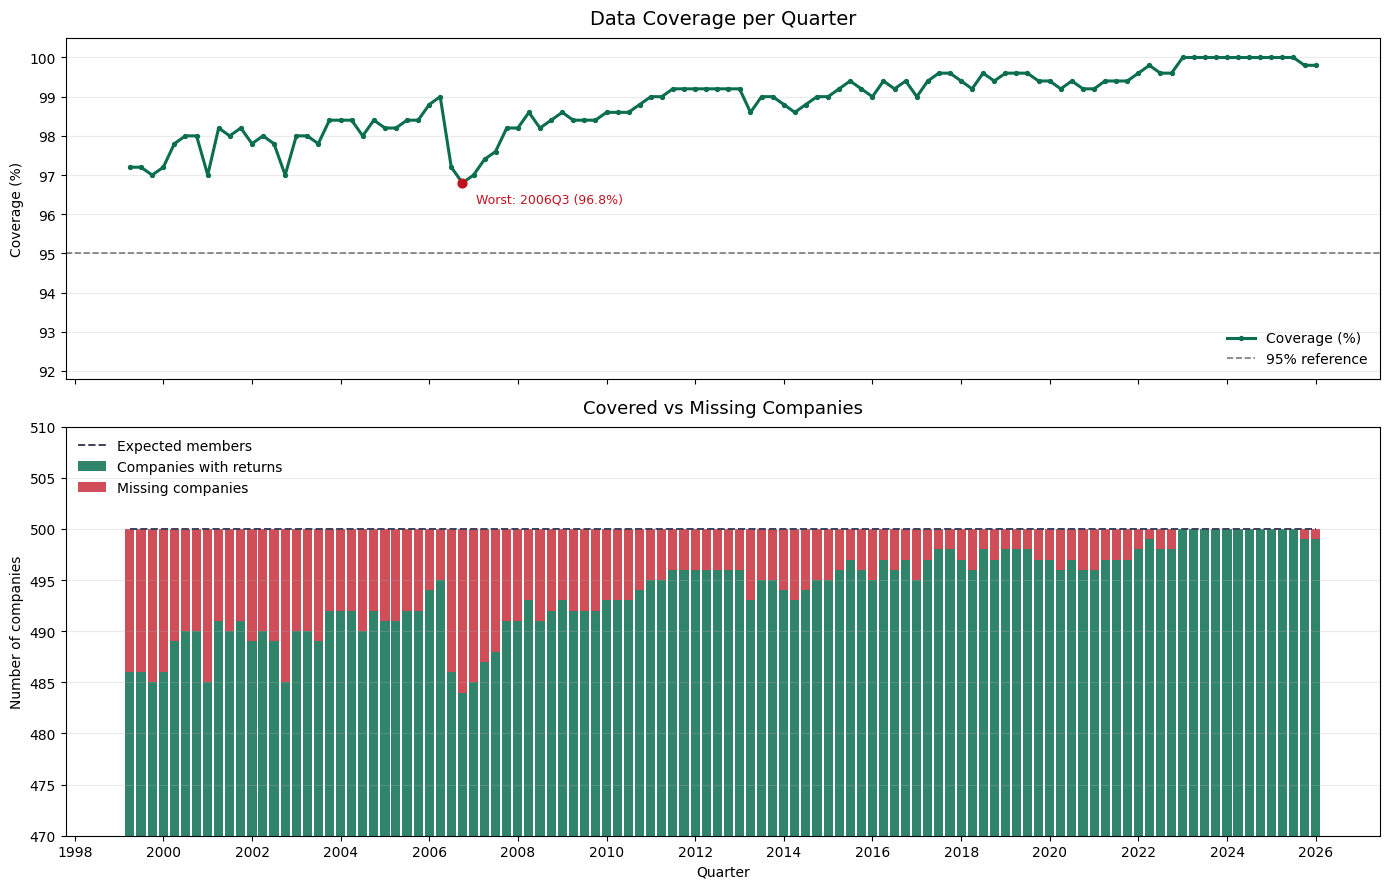

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

returns_in_index = pd.read_parquet(OUTPUT_RETURNS_IN_INDEX)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype("string")

# Erwartete Firmenzahl je Quartal aus dem Universe
universe_q = (
    df.groupby("quarter", as_index=False)
    .agg(n_members=("company_key", "nunique"))
)
universe_q["quarter"] = universe_q["quarter"].astype("string")

coverage_q = (
    returns_in_index
    .groupby("quarter", as_index=False)
    .agg(
        n_obs=("ret", "size"),
        n_companies=("company_key", "nunique"),
        n_dates=("date", "nunique"),
    )
    .merge(universe_q, on="quarter", how="right")
)

coverage_q["n_obs"] = coverage_q["n_obs"].fillna(0).astype(int)
coverage_q["n_companies"] = coverage_q["n_companies"].fillna(0).astype(int)
coverage_q["n_dates"] = coverage_q["n_dates"].fillna(0).astype(int)
coverage_q["n_members"] = coverage_q["n_members"].fillna(0).astype(int)

coverage_q["missing_companies"] = (coverage_q["n_members"] - coverage_q["n_companies"]).clip(lower=0)
coverage_q["coverage_pct"] = np.where(
    coverage_q["n_members"] > 0,
    100.0 * coverage_q["n_companies"] / coverage_q["n_members"],
    np.nan,
)
coverage_q["avg_obs_per_company"] = np.where(
    coverage_q["n_companies"] > 0,
    coverage_q["n_obs"] / coverage_q["n_companies"],
    np.nan,
)
coverage_q["quarter_end"] = pd.PeriodIndex(coverage_q["quarter"].astype(str), freq="Q").to_timestamp(how="end")
coverage_q = coverage_q.sort_values("quarter_end").reset_index(drop=True)

if coverage_q.empty:
    raise ValueError("coverage_q is empty. Check OUTPUT_RETURNS_IN_INDEX and universe input.")

worst_idx = coverage_q["coverage_pct"].idxmin()
worst = coverage_q.loc[worst_idx]
latest = coverage_q.iloc[-1]

kpi = pd.DataFrame(
    {
        "metric": [
            "Quarters analyzed",
            "Mean coverage (%)",
            "Median coverage (%)",
            "Quarters < 95% coverage",
            "Worst quarter (coverage %)",
            "Latest quarter (coverage %)",
            "Latest missing companies",
        ],
        "value": [
            int(len(coverage_q)),
            round(float(coverage_q["coverage_pct"].mean()), 2),
            round(float(coverage_q["coverage_pct"].median()), 2),
            int((coverage_q["coverage_pct"] < 95).sum()),
            f"{worst['quarter']} ({worst['coverage_pct']:.2f}%)",
            f"{latest['quarter']} ({latest['coverage_pct']:.2f}%)",
            int(latest["missing_companies"]),
        ],
    }
)
print(kpi.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1.2]},
)

# Plot 1: Coverage-Quote
ax1.plot(
    coverage_q["quarter_end"],
    coverage_q["coverage_pct"],
    color="#0B6E4F",
    linewidth=2.2,
    marker="o",
    markersize=2.8,
    label="Coverage (%)",
)
ax1.axhline(95, color="#7A7A7A", linewidth=1.2, linestyle="--", label="95% reference")
ax1.fill_between(
    coverage_q["quarter_end"],
    coverage_q["coverage_pct"],
    95,
    where=coverage_q["coverage_pct"] < 95,
    color="#C1121F",
    alpha=0.15,
)
ax1.scatter([worst["quarter_end"]], [worst["coverage_pct"]], color="#C1121F", s=40, zorder=5)
ax1.annotate(
    f"Worst: {worst['quarter']} ({worst['coverage_pct']:.1f}%)",
    xy=(worst["quarter_end"], worst["coverage_pct"]),
    xytext=(10, -14),
    textcoords="offset points",
    color="#C1121F",
    fontsize=9,
)
ax1.set_title("Data Coverage per Quarter", fontsize=14, pad=10)
ax1.set_ylabel("Coverage (%)")
ax1.set_ylim(max(0, float(np.nanmin(coverage_q["coverage_pct"])) - 5), 100.5)
ax1.grid(axis="y", alpha=0.25)
ax1.legend(loc="lower right", frameon=False)

# Plot 2: Abgedeckte vs fehlende Firmen
ax2.bar(
    coverage_q["quarter_end"],
    coverage_q["n_companies"],
    width=75,
    color="#0B6E4F",
    alpha=0.85,
    label="Companies with returns",
)
ax2.bar(
    coverage_q["quarter_end"],
    coverage_q["missing_companies"],
    width=75,
    bottom=coverage_q["n_companies"],
    color="#C1121F",
    alpha=0.75,
    label="Missing companies",
)
ax2.plot(
    coverage_q["quarter_end"],
    coverage_q["n_members"],
    color="#3D405B",
    linewidth=1.4,
    linestyle="--",
    label="Expected members",
)
ax2.set_title("Covered vs Missing Companies", fontsize=13, pad=10)
ax2.set_ylabel("Number of companies")
ax2.set_xlabel("Quarter")
ax2.set_ylim(470, max(460, int(coverage_q["n_members"].max()) + 10))
ax2.grid(axis="y", alpha=0.25)
ax2.legend(loc="upper left", frameon=False)

ax2.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


## 8. Top 15 Missing-Unternehmen (meiste Quartale im Index)

Diese Zelle zeigt nur die 15 fehlenden Unternehmen mit den meisten Quartalen im EURO500-Universum.
Ausgabe-Spalten: `name`, `firmid`, `ric`, `isin` sowie `n_quarters_in_index` als Ranking-Metrik.



In [9]:
# Post-Processing only: keine LSEG-Session, kein neuer Datenpull
# NOTE: No additional files are written in this section.

missing_in = OUTPUT_MISSING
euro_in = EURO500_PATH

if not missing_in.exists():
    raise FileNotFoundError(f"Missing file not found: {missing_in}")
if not euro_in.exists():
    raise FileNotFoundError(f"euro500 file not found: {euro_in}")

missing = pd.read_parquet(missing_in).copy()
euro = pd.read_parquet(euro_in).copy()

for c in ["firm_id", "ISIN", "RIC", "RIC_current", "name", "quarter"]:
    if c in euro.columns:
        euro[c] = euro[c].astype("string").str.strip()
        euro.loc[euro[c] == "", c] = pd.NA

# company_key analog zur Pull-Logik rekonstruieren
euro["id_type"] = np.select(
    [euro["ISIN"].notna(), euro["RIC_current"].notna(), euro["RIC"].notna()],
    ["ISIN", "RIC", "RIC"],
    default=pd.NA,
)
euro["pull_id"] = np.select(
    [euro["ISIN"].notna(), euro["RIC_current"].notna(), euro["RIC"].notna()],
    [euro["ISIN"], euro["RIC_current"], euro["RIC"]],
    default=pd.NA,
)
euro["company_key"] = euro["id_type"].astype("string") + ":" + euro["pull_id"].astype("string")
euro.loc[euro["pull_id"].isna(), "company_key"] = pd.NA

# Quartalsabdeckung je Unternehmen
quarter_counts = (
    euro[["company_key", "quarter"]]
    .dropna(subset=["company_key", "quarter"])
    .drop_duplicates()
    .groupby("company_key", as_index=False)
    .agg(n_quarters_in_index=("quarter", "nunique"))
)

# Metadaten je Unternehmen
meta = (
    euro[["company_key", "name", "firm_id", "RIC", "RIC_current", "ISIN"]]
    .dropna(subset=["company_key"])
    .drop_duplicates(subset=["company_key"], keep="first")
)

missing_enriched = (
    missing.merge(meta, on="company_key", how="left", suffixes=("", "_meta"))
    .merge(quarter_counts, on="company_key", how="left")
)

# Fehlende Felder mit Meta-Infos auffuellen
for col in ["firm_id", "ISIN", "RIC", "RIC_current"]:
    mcol = f"{col}_meta"
    if mcol in missing_enriched.columns:
        if col in missing_enriched.columns:
            missing_enriched[col] = missing_enriched[col].fillna(missing_enriched[mcol])
        else:
            missing_enriched[col] = missing_enriched[mcol]

if "name_meta" in missing_enriched.columns:
    name_fallback = missing_enriched["name_meta"].astype("string")
elif "name" in missing_enriched.columns:
    name_fallback = missing_enriched["name"].astype("string")
else:
    name_fallback = pd.Series(pd.NA, index=missing_enriched.index, dtype="string")

if "company_name" in missing_enriched.columns:
    missing_enriched["company_name"] = missing_enriched["company_name"].astype("string").fillna(name_fallback)
else:
    missing_enriched["company_name"] = name_fallback

missing_enriched["n_quarters_in_index"] = missing_enriched["n_quarters_in_index"].fillna(0).astype(int)

# RIC: priorisiere RIC_current, fallback RIC
ric_series = pd.Series(pd.NA, index=missing_enriched.index, dtype="string")
if "RIC_current" in missing_enriched.columns:
    ric_series = missing_enriched["RIC_current"].astype("string")
if "RIC" in missing_enriched.columns:
    ric_series = ric_series.fillna(missing_enriched["RIC"].astype("string"))

result = pd.DataFrame(
    {
        "company_key": missing_enriched["company_key"].astype("string") if "company_key" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "name": missing_enriched["company_name"].astype("string"),
        "firmid": missing_enriched["firm_id"].astype("string") if "firm_id" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "ric": ric_series,
        "isin": missing_enriched["ISIN"].astype("string") if "ISIN" in missing_enriched.columns else pd.Series(pd.NA, index=missing_enriched.index, dtype="string"),
        "n_quarters_in_index": missing_enriched["n_quarters_in_index"],
    }
)

result = (
    result
    .sort_values(["n_quarters_in_index", "name"], ascending=[False, True], na_position="last")
    .drop_duplicates(subset=["company_key"], keep="first")
    .head(15)
    .reset_index(drop=True)
)

result = result[["name", "firmid", "ric", "isin", "n_quarters_in_index"]]

print(f"Missing companies total: {missing['company_key'].nunique() if 'company_key' in missing.columns else len(missing)}")
print("Top 15 missing companies by quarters in index:")
print(result.to_string(index=False))



Missing companies total: 25
Top 15 missing companies by quarters in index:
                                         name      firmid             ric         isin  n_quarters_in_index
                   BIP Investment Partners SA FIRM0002718 LU0110790085.BR LU0110790085                   24
                                  Funkwerk AG FIRM0000840        FEW0n.TG DE0005753149                   18
                                 Claranova SE FIRM0000537        ALCLA.PA FR0004152882                    9
                                 Meta Wolf AG FIRM0000633        WOLFG.DE DE000A254203                    8
          Heidelberger Beteiligungsholding AG FIRM0002807        IPOKk.DE DE000A254294                    7
                                 Ls Invest AG FIRM0000589          IFAG.H DE0006131204                    6
Compania Espanola de Viviendas en Alquiler SA FIRM0000547          CEV.MC ES0132955016                    5
                               Materialise NV FIRM0001638    